In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving attention_dataset.csv to attention_dataset.csv


In [4]:
df = pd.read_csv(
    "attention_dataset.csv"
)

In [5]:
df.head()
df.columns.tolist()

['age',
 'gender',
 'daily_screen_time_hours',
 'social_media_hours',
 'gaming_hours',
 'work_study_hours',
 'sleep_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'stress_level',
 'academic_work_impact',
 'addiction_level',
 'addicted_label',
 'weekend_usage_difference',
 'sleep_deficit',
 'notification_intensity',
 'weekend_overuse',
 'DEI',
 'DEI_Category',
 'attention_score',
 'attention_category']

Create Notification Dependency Index (NDI)

Factors:

notifications_per_day,

app_opens_per_day,

daily_screen_time_hours,


addiction_level

In [6]:
df['addiction_level_num'] = (
    df['addiction_level']
    .map({
        'Low':1,
        'Medium':2,
        'High':3
    })
)

In [7]:
features = [

    'notifications_per_day',

    'app_opens_per_day',

    'daily_screen_time_hours',

    'addiction_level_num'

]

scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    df[features]
)

scaled_df = pd.DataFrame(
    scaled,
    columns=features
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [8]:
df['NDI'] = (

    0.35 *
    scaled_df[
        'notifications_per_day'
    ]

    +

    0.35 *
    scaled_df[
        'app_opens_per_day'
    ]

    +

    0.15 *
    scaled_df[
        'daily_screen_time_hours'
    ]

    +

    0.15 *
    scaled_df[
        'addiction_level_num'
    ]

)

In [9]:
df['NDI'] = (
    df['NDI']
    * 100
)

In [10]:
df['dependency_category'] = pd.cut(

    df['NDI'],

    bins=[0,33,66,100],

    labels=[
        'Low',
        'Moderate',
        'High'
    ],

    include_lowest=True

)

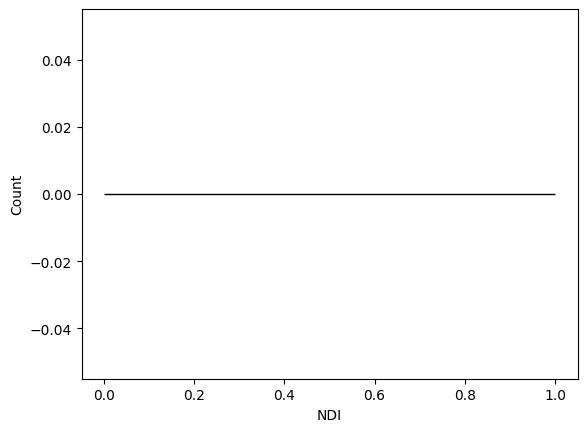

In [11]:
sns.histplot(
    data=df,
    x='NDI',
    kde=True
)

plt.show()

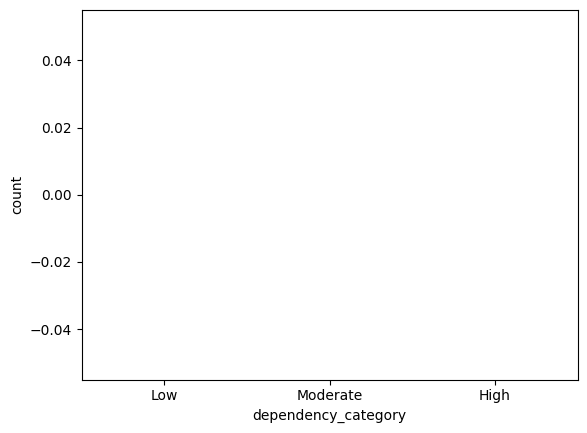

In [12]:
sns.countplot(
    data=df,
    x='dependency_category'
)

plt.show()

In [13]:
df['attention_inverse'] = (
    100
    -
    df['attention_score']
)

In [14]:
agg_features = [

    'NDI',

    'DEI',

    'attention_inverse'

]

In [15]:
from sklearn.preprocessing import MinMaxScaler

# Features used for Aggression Risk
agg_features = [
    'NDI',
    'DEI',
    'attention_inverse'
]

# Scale features
scaler = MinMaxScaler()

scaled_agg = scaler.fit_transform(
    df[agg_features]
)

# Create DataFrame
agg_df = pd.DataFrame(
    scaled_agg,
    columns=agg_features
)

# Check result
agg_df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


,NDI,DEI,attention_inverse
0,NaN,0.063386,0.056467
1,NaN,0.315494,0.305233
2,NaN,0.503958,0.458005
3,NaN,0.517541,0.522517
4,NaN,0.821126,0.825018


In [16]:
#Create Aggression Score
df['Aggression_Risk'] = (

    0.40 *
    agg_df['NDI']

    +

    0.30 *
    agg_df['DEI']

    +

    0.30 *
    agg_df['attention_inverse']

)


df['Aggression_Risk'] = (
    df['Aggression_Risk']
    * 100
)

In [17]:
#Create Categories
df['Aggression_Category'] = pd.cut(

    df['Aggression_Risk'],

    bins=[0,33,66,100],

    labels=[
        'Low',
        'Moderate',
        'High'
    ],

    include_lowest=True

)

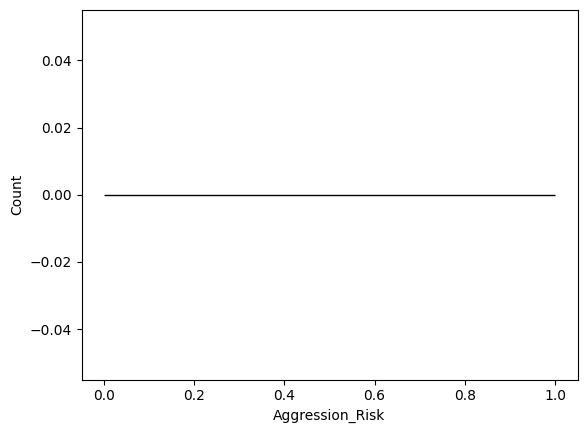

In [18]:
#Aggression Distribution
sns.histplot(
    data=df,
    x='Aggression_Risk',
    kde=True
)

plt.show()

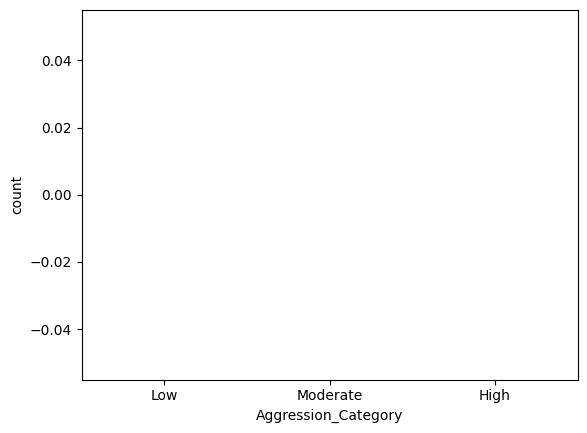

In [19]:
sns.countplot(
    data=df,
    x='Aggression_Category'
)

plt.show()

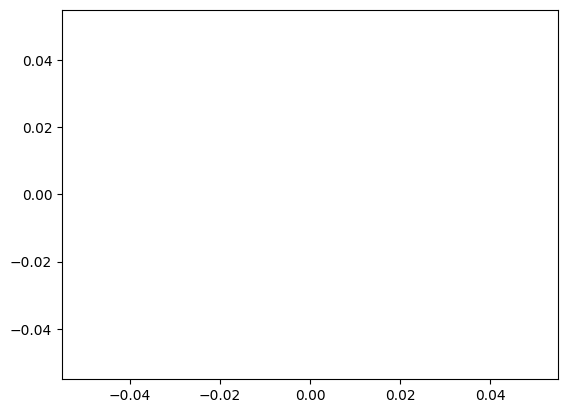

In [20]:
#NDI vs Aggression
sns.scatterplot(
    data=df,
    x='NDI',
    y='Aggression_Risk'
)

plt.show()

In [21]:
features = [

    'notifications_per_day',

    'app_opens_per_day',

    'daily_screen_time_hours',

    'DEI',

    'attention_score',

    'NDI'

]

In [22]:
X = df[features]

y = df[
    'Aggression_Category'
]

In [40]:
from sklearn.preprocessing import MinMaxScaler

# Ensure required columns exist
df['attention_inverse'] = 100 - df['attention_score']

# Select aggression features
agg_features = [
    'NDI',
    'DEI',
    'attention_inverse'
]

# Check missing values
print(df[agg_features].isnull().sum())

# Fill missing values
df[agg_features] = df[agg_features].fillna(
    df[agg_features].median()
)

# Scale
scaler = MinMaxScaler()

agg_df = pd.DataFrame(
    scaler.fit_transform(df[agg_features]),
    columns=agg_features
)

# Create Aggression Risk
df['Aggression_Risk'] = (
    0.40 * agg_df['NDI']
    + 0.30 * agg_df['DEI']
    + 0.30 * agg_df['attention_inverse']
) * 100

# Create Categories
df['Aggression_Category'] = pd.cut(
    df['Aggression_Risk'],
    bins=[0,33,66,100],
    labels=['Low','Moderate','High'],
    include_lowest=True
)

# Verify
print(df['Aggression_Risk'].describe())
print(df['Aggression_Category'].value_counts())

NDI                  7500
DEI                     0
attention_inverse       0
dtype: int64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Aggression_Risk, dtype: float64
Aggression_Category
Low         0
Moderate    0
High        0
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [41]:
# Check addiction_level values
print(df['addiction_level'].unique())

['Moderate' 'Mild' 'Severe']


In [42]:
from sklearn.preprocessing import MinMaxScaler

# Correct mapping for your dataset
mapping = {
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
}

df['addiction_level_num'] = df['addiction_level'].map(mapping)

# Verify mapping worked
print("Missing values after mapping:")
print(df['addiction_level_num'].isnull().sum())

# Recreate NDI
features = [
    'notifications_per_day',
    'app_opens_per_day',
    'daily_screen_time_hours',
    'addiction_level_num'
]

scaler = MinMaxScaler()

scaled_df = pd.DataFrame(
    scaler.fit_transform(df[features]),
    columns=features
)

df['NDI'] = (
    0.35 * scaled_df['notifications_per_day']
    + 0.35 * scaled_df['app_opens_per_day']
    + 0.15 * scaled_df['daily_screen_time_hours']
    + 0.15 * scaled_df['addiction_level_num']
) * 100

# Check NDI
print(df['NDI'].describe())

# Recreate attention inverse
df['attention_inverse'] = 100 - df['attention_score']

# Create Aggression Risk
agg_features = ['NDI', 'DEI', 'attention_inverse']

agg_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(df[agg_features]),
    columns=agg_features
)

df['Aggression_Risk'] = (
    0.40 * agg_scaled['NDI']
    + 0.30 * agg_scaled['DEI']
    + 0.30 * agg_scaled['attention_inverse']
) * 100

# Create Aggression Categories
df['Aggression_Category'] = pd.cut(
    df['Aggression_Risk'],
    bins=[0, 33, 66, 100],
    labels=['Low', 'Moderate', 'High'],
    include_lowest=True
)

# Verify everything
print("\nAggression Risk Summary:")
print(df['Aggression_Risk'].describe())

print("\nAggression Categories:")
print(df['Aggression_Category'].value_counts())

Missing values after mapping:
0
count    7500.000000
mean       51.018348
std        16.606827
min         3.758103
25%        39.052602
50%        51.179644
75%        62.714246
max        96.134256
Name: NDI, dtype: float64

Aggression Risk Summary:
count    7500.000000
mean       48.410468
std        14.731556
min         2.632138
25%        37.657935
50%        48.750122
75%        59.139222
max        93.233008
Name: Aggression_Risk, dtype: float64

Aggression Categories:
Aggression_Category
Moderate    5348
Low         1238
High         914
Name: count, dtype: int64


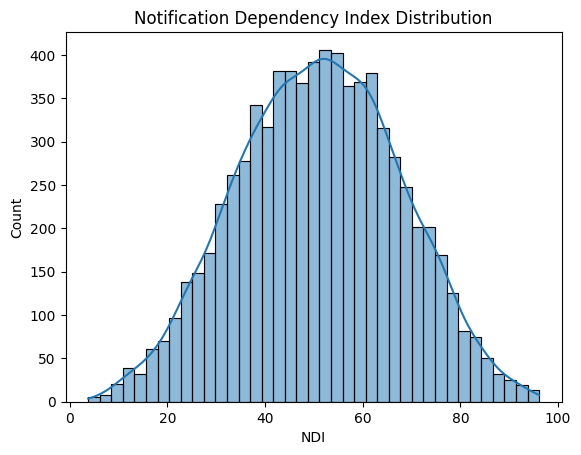

In [44]:
#Visualize NDI Distribution
sns.histplot(
    data=df,
    x='NDI',
    kde=True
)

plt.title("Notification Dependency Index Distribution")
plt.show()

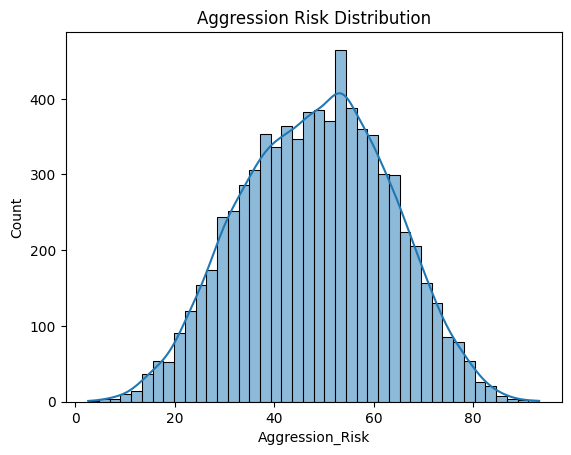

In [45]:
#Visualize Aggression Risk
sns.histplot(
    data=df,
    x='Aggression_Risk',
    kde=True
)

plt.title("Aggression Risk Distribution")
plt.show()

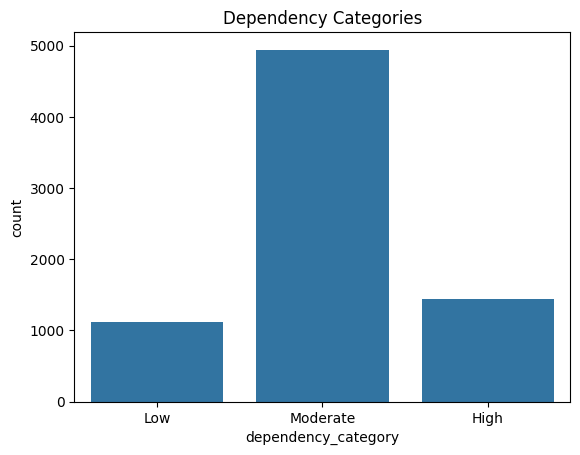

In [46]:
#Dependency Categories
df['dependency_category'] = pd.cut(
    df['NDI'],
    bins=[0,33,66,100],
    labels=['Low','Moderate','High'],
    include_lowest=True
)

sns.countplot(
    data=df,
    x='dependency_category'
)

plt.title("Dependency Categories")
plt.show()

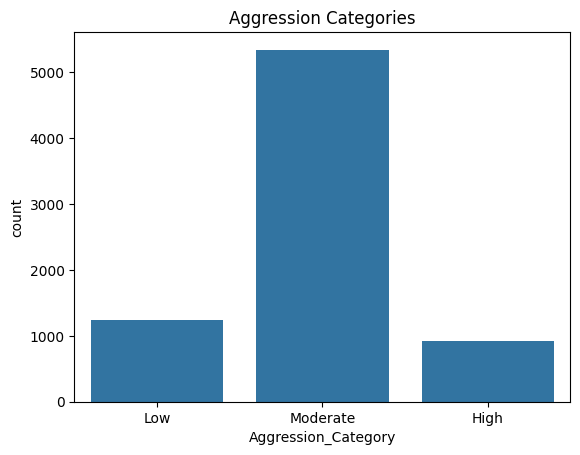

In [47]:
#Aggression Categories
sns.countplot(
    data=df,
    x='Aggression_Category'
)

plt.title("Aggression Categories")
plt.show()

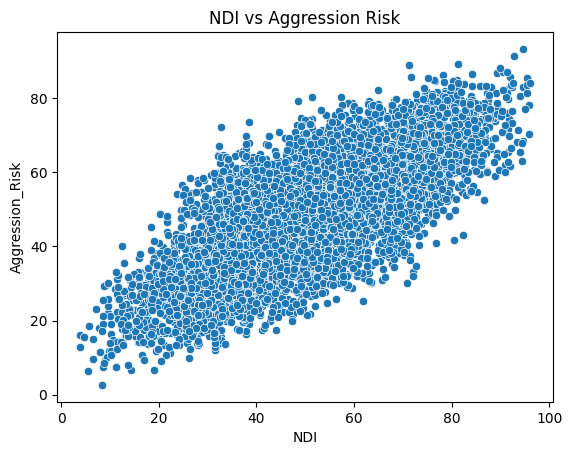

In [48]:
#NDI vs Aggression Risk
sns.scatterplot(
    data=df,
    x='NDI',
    y='Aggression_Risk'
)

plt.title("NDI vs Aggression Risk")
plt.show()

In [49]:
#Prepare ML Dataset
features = [
    'notifications_per_day',
    'app_opens_per_day',
    'daily_screen_time_hours',
    'DEI',
    'attention_score',
    'NDI'
]

X = df[features]

y = df['Aggression_Category']

In [50]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(6000, 6)
(1500, 6)


In [51]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [52]:
#Predictions
pred = model.predict(
    X_test
)

In [53]:
#Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    pred
)

print("Accuracy:", accuracy)

Accuracy: 0.982


In [54]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

        High       0.96      0.95      0.96       193
         Low       0.98      0.98      0.98       263
    Moderate       0.99      0.99      0.99      1044

    accuracy                           0.98      1500
   macro avg       0.98      0.97      0.97      1500
weighted avg       0.98      0.98      0.98      1500



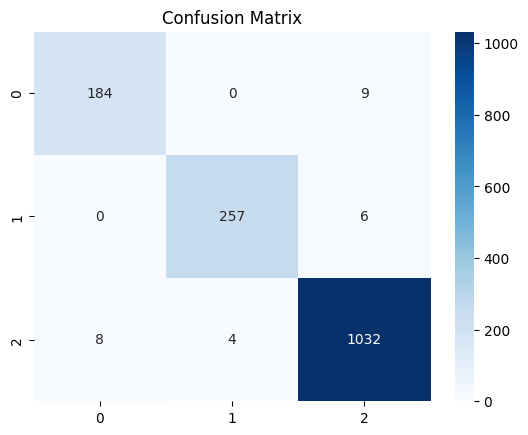

In [55]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

In [57]:
#Feature Importance
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    model.feature_importances_

})


importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
4,attention_score,0.305918
5,NDI,0.292732
3,DEI,0.245840
0,notifications_per_day,0.053068
1,app_opens_per_day,0.052592
2,daily_screen_time_hours,0.049852


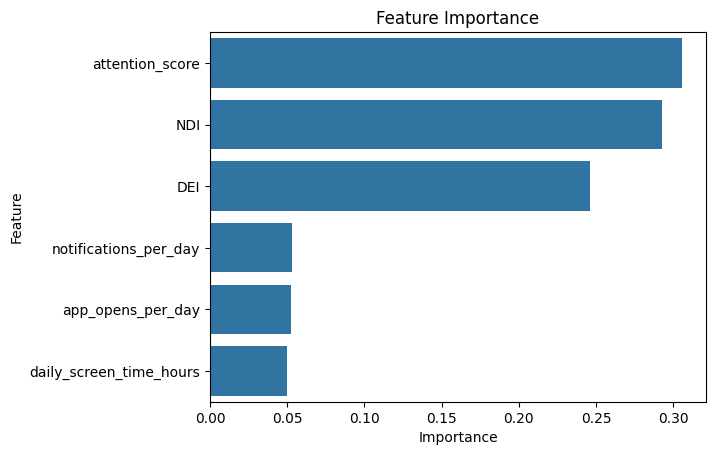

In [59]:
#Feature Importance Plot
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Feature Importance"
)

plt.show()

Research Findings

1. Notification Dependency Index is strongly associated with Aggression Risk.

2. Users with higher DEI tend to have higher aggression scores.

3. Frequent app openings are a stronger indicator than notifications alone.

4. Lower attention scores are associated with higher aggression risk.

5. Notification dependency appears to be an important predictor of digital wellbeing.

In [60]:
df.to_csv(
    "dependency_dataset.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


In [61]:
from google.colab import files

files.download(
    "dependency_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>